In [2]:
import sys
print(sys.executable)

/Users/arpitsmac/Documents/NyayLens/.venv/bin/python


In [3]:
import pandas as pd
import pyarrow as pa
print("Pandas version:",pd.__version__)
print("Pyarrow version:",pa.__version__)

Pandas version: 3.0.6
Pyarrow version: 25.0.1


In [4]:
df = pd.read_parquet("/Users/arpitsmac/Documents/NyayLens/data/raw/metadata_2025.parquet")

In [5]:
df.shape

(897, 18)

In [6]:
df.columns.tolist()

['title',
 'petitioner',
 'respondent',
 'description',
 'judge',
 'author_judge',
 'citation',
 'case_id',
 'cnr',
 'decision_date',
 'disposal_nature',
 'court',
 'available_languages',
 'raw_html',
 'path',
 'nc_display',
 'scraped_at',
 'year']

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 897 entries, 0 to 896
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                897 non-null    string
 1   petitioner           897 non-null    string
 2   respondent           897 non-null    string
 3   description          897 non-null    string
 4   judge                897 non-null    string
 5   author_judge         0 non-null      string
 6   citation             897 non-null    string
 7   case_id              897 non-null    string
 8   cnr                  897 non-null    string
 9   decision_date        897 non-null    string
 10  disposal_nature      897 non-null    string
 11  court                897 non-null    string
 12  available_languages  897 non-null    string
 13  raw_html             897 non-null    string
 14  path                 897 non-null    string
 15  nc_display           897 non-null    string
 16  scraped_at         

In [8]:
df.isna().sum().sort_values(ascending = False)

author_judge           897
title                    0
disposal_nature          0
scraped_at               0
nc_display               0
path                     0
raw_html                 0
available_languages      0
court                    0
decision_date            0
petitioner               0
cnr                      0
case_id                  0
citation                 0
judge                    0
description              0
respondent               0
year                     0
dtype: int64

In [9]:
df.head(3).T

,0,1,2
title,KRISHNA DEVI @ SABITRI DEVI (RANI) M/S S.R. EN...,JIT VINAYAK AROLKAR versus STATE OF GOA & ORS.,GEETHA V.M. & ORS. versus RETHNASENAN K. & ORS.
petitioner,KRISHNA DEVI @ SABITRI DEVI (RANI) M/S S.R. EN...,JIT VINAYAK AROLKAR,GEETHA V.M. & ORS.
respondent,UNION OF INDIA & ORS.,STATE OF GOA & ORS.,RETHNASENAN K. & ORS.
description,,,
judge,PAMIDIGHANTAM SRI NARASIMHA,ABHAY S. OKA,J.K. MAHESHWARI
author_judge,<NA>,<NA>,<NA>
citation,[2025] 1 S.C.R. 81,[2025] 1 S.C.R. 230,[2025] 1 S.C.R. 515
case_id,2025 INSC 24,2025 INSC 31,2025 INSC 33
cnr,ESCR010000052025,ESCR010000152025,ESCR010000292025
decision_date,02-01-2025,05-01-2025,02-01-2025


In [10]:
df["disposal_nature"].value_counts()

disposal_nature
Appeal(s) allowed                  418
Dismissed                          193
Disposed off                       152
                                    47
Case Partly allowed                 41
Case Allowed                        19
Directions issued                   18
Reference answered                   4
Rejected                             3
Matter referred to larger bench      2
Name: count, dtype: int64[pyarrow]

In [11]:
df["available_languages"]

0          ENG,NEP,PUN
1      ENG,MAR,NEP,PUN
2          ENG,MAL,PUN
3          ENG,NEP,PUN
4              ENG,PUN
            ...       
892                   
893                   
894                   
895                   
896                   
Name: available_languages, Length: 897, dtype: string

In [12]:
df["court"]

0      Supreme Court of India
1      Supreme Court of India
2      Supreme Court of India
3      Supreme Court of India
4      Supreme Court of India
                ...          
892    Supreme Court of India
893    Supreme Court of India
894    Supreme Court of India
895    Supreme Court of India
896    Supreme Court of India
Name: court, Length: 897, dtype: string

In [13]:
df["judge"].value_counts().head(20)


judge
VIKRAM NATH                                      106
J.B. PARDIWALA                                    96
ABHAY S. OKA                                      79
SUDHANSHU DHULIA                                  62
BHUSHAN RAMKRISHNA GAVAI                          58
PAMIDIGHANTAM SRI NARASIMHA                       57
B.V. NAGARATHNA                                   52
DIPANKAR DATTA                                    52
J.B. PARDIWALA, R MAHADEVAN                       43
SANJAY KAROL                                      35
SURYA KANT                                        29
J.K. MAHESHWARI                                   24
PANKAJ MITHAL                                     24
SANJAY KUMAR                                      15
BELA M. TRIVEDI                                   12
SANJIV KHANNA                                     11
AHSANUDDIN AMANULLAH                              11
MANOJ MISRA                                        9
M.M. SUNDRESH                           

In [14]:
df["year"].value_counts()

year
2025    897
Name: count, dtype: int64[pyarrow]

In [15]:
df["disposal_nature"].str.strip().eq("").sum()

47

In [16]:
df["disposal_nature"].unique()

<ArrowStringArray>
[              'Appeal(s) allowed',                    'Disposed off',
                       'Dismissed',             'Case Partly allowed',
 'Matter referred to larger bench',               'Directions issued',
                                '',                    'Case Allowed',
              'Reference answered',                        'Rejected']
Length: 10, dtype: string

In [17]:
df["description"].head(10).tolist()

['', '', '', '', '', '', '', '', '', '']

In [18]:
df["description"].str.strip().eq("").sum()

141

In [19]:
language_count = df["available_languages"].str.split(",").explode().value_counts()

In [20]:
print(language_count)

available_languages
       758
ENG    139
PUN    112
HIN     47
NEP     11
MAR      2
MAL      2
ORI      1
Name: count, dtype: int64


In [21]:
df["path"].nunique()

897

In [22]:
df["path"].head(20).tolist()

['2025_1_81_92',
 '2025_1_230_238',
 '2025_1_515_541',
 '2025_1_184_189',
 '2025_1_446_461',
 '2025_1_239_265',
 '2025_1_266_280',
 '2025_1_105_116',
 '2025_1_158_176',
 '2025_1_130_150',
 '2025_1_151_157',
 '2025_1_62_80',
 '2025_1_576_591',
 '2025_1_431_445',
 '2025_1_177_183',
 '2025_1_117_129',
 '2025_1_40_61',
 '2025_1_12_39',
 '2025_1_93_104',
 '2025_1_1_11']

In [23]:
df["case_id"].nunique()

894

In [24]:
df[["case_id","path"]].head(20).values.tolist()

[['2025 INSC 24', '2025_1_81_92'],
 ['2025 INSC 31', '2025_1_230_238'],
 ['2025 INSC 33', '2025_1_515_541'],
 ['2025 INSC 30', '2025_1_184_189'],
 ['2025 INSC 34', '2025_1_446_461'],
 ['2025 INSC 2', '2025_1_239_265'],
 ['2025 INSC 27', '2025_1_266_280'],
 ['2025 INSC 20', '2025_1_105_116'],
 ['2025 INSC 22', '2025_1_158_176'],
 ['2025 INSC 11', '2025_1_130_150'],
 ['2025 INSC 26', '2025_1_151_157'],
 ['2025 INSC 14', '2025_1_62_80'],
 ['2025 INSC 44', '2025_1_576_591'],
 ['2025 INSC 38', '2025_1_431_445'],
 ['2025 INSC 25', '2025_1_177_183'],
 ['2025 INSC 21', '2025_1_117_129'],
 ['2025 INSC 1', '2025_1_40_61'],
 ['2025 INSC 4', '2025_1_12_39'],
 ['2025 INSC 18', '2025_1_93_104'],
 ['2025 INSC 8', '2025_1_1_11']]

In [25]:
df[df["case_id"].duplicated(keep=False)].sort_values("case_id").T

,542,561,303,312,684,775
title,SURENDRA KOLI versus THE STATE OF UTTAR PRADES...,THE STATE OF JHARKHAND versus THE INDIAN BUILD...,ANMOL versus UNION OF INDIA & ORS.,THE STATE OF CHATTISGARH versus ASHOK BHOI ETC.,SACHIN versus THE STATE OF MAHARASHTRA,THE STATE OF KERALA ETC. ETC. versus THE PRINC...
petitioner,SURENDRA KOLI,THE STATE OF JHARKHAND,ANMOL,THE STATE OF CHATTISGARH,SACHIN,THE STATE OF KERALA ETC. ETC.
respondent,THE STATE OF UTTAR PRADESH & ANR.,THE INDIAN BUILDERS JAMSHEDPUR,UNION OF INDIA & ORS.,ASHOK BHOI ETC.,THE STATE OF MAHARASHTRA,"THE PRINCIPAL, KMCT MEDICAL COLLEGE AND ORS. E..."
description,Issue for Consideration Whether the present ca...,Issue for Consideration Bharat Drilling & Foun...,Issue for Consideration Appellant appeared in ...,Issue for Consideration Whether the High Court...,Issue for Consideration Whether it is a fit ca...,Issue for Consideration (a) Whether the Admiss...
judge,BHUSHAN RAMKRISHNA GAVAI,PAMIDIGHANTAM SRI NARASIMHA,BHUSHAN RAMKRISHNA GAVAI,"BELA M. TRIVEDI, PRASANNA BHALACHANDRA VARALE","B.V. NAGARATHNA, SATISH CHANDRA SHARMA",SURYA KANT
author_judge,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
citation,[2025] 12 S.C.R. 152,[2025] 12 S.C.R. 417,[2025] 2 S.C.R. 1142,[2025] 2 S.C.R. 1785,[2025] 4 S.C.R. 2497,[2025] 5 S.C.R. 2593
case_id,2025 INSC 1308,2025 INSC 1308,2025 INSC 256,2025 INSC 256,2025 INSC 518,2025 INSC 518
cnr,ESCR010006602025,ESCR010006752025,ESCR010003022025,ESCR010003522025,ESCR010007072025,ESCR010008392025
decision_date,11-11-2025,05-12-2025,21-02-2025,27-02-2025,21-04-2025,16-05-2025


In [26]:
clean_df = df.copy()

In [27]:
clean_df.isna().sum().sort_values(ascending = False)

author_judge           897
title                    0
disposal_nature          0
scraped_at               0
nc_display               0
path                     0
raw_html                 0
available_languages      0
court                    0
decision_date            0
petitioner               0
cnr                      0
case_id                  0
citation                 0
judge                    0
description              0
respondent               0
year                     0
dtype: int64

In [28]:
string_cols = df.select_dtypes(include = "string").columns
type(string_cols)

pandas.Index

In [29]:
for col in string_cols:
    clean_df[col] = clean_df[col].str.strip()
    clean_df[col] = clean_df[col].replace("",pd.NA)

In [30]:
clean_df.isna().sum().sort_values(ascending = False)

author_judge           897
available_languages    758
description            141
disposal_nature         47
respondent              11
petitioner              11
judge                    1
title                    0
scraped_at               0
nc_display               0
path                     0
raw_html                 0
decision_date            0
court                    0
cnr                      0
case_id                  0
citation                 0
year                     0
dtype: int64

In [31]:
clean_df["decision_date"] = pd.to_datetime(clean_df["decision_date"], format = "%d-%m-%Y")

In [32]:
clean_df[["decision_date","year"]].head(5)

,decision_date,year
0,2025-01-02,2025
1,2025-01-05,2025
2,2025-01-02,2025
3,2025-01-05,2025
4,2025-01-01,2025


In [33]:
clean_df.dtypes

title                          string
petitioner                     string
respondent                     string
description                    string
judge                          string
author_judge                   string
citation                       string
case_id                        string
cnr                            string
decision_date          datetime64[us]
disposal_nature                string
court                          string
available_languages            string
raw_html                       string
path                           string
nc_display                     string
scraped_at                     string
year                           string
dtype: object

In [34]:
clean_df["year"] = clean_df["year"].astype("int16")

In [35]:
(clean_df["decision_date"].dt.year != clean_df["year"]).sum()

np.int64(0)

In [40]:
monthly_judgements = (clean_df["decision_date"].dt.month.value_counts().sort_index())
monthly_judgements

decision_date
1     107
2     103
3      88
4     143
5     126
6      10
7      89
8      95
9      64
10     24
11     26
12     22
Name: count, dtype: int64

In [45]:
import matplotlib.pyplot as plt
import calendar

In [47]:
monthly_judgements.index = [ calendar.month_abbr[m] for m in monthly_judgements.index]

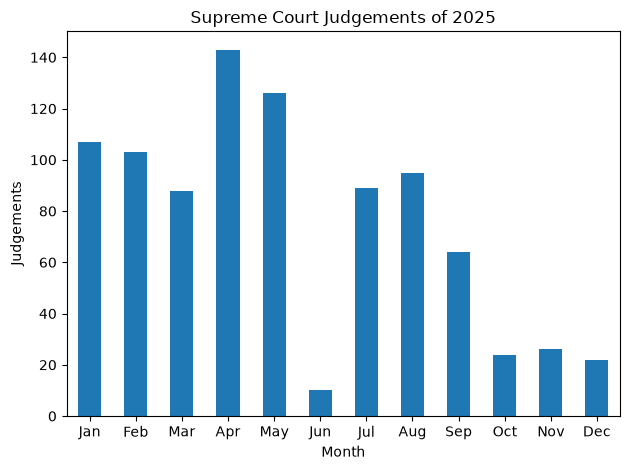

In [51]:
monthly_judgements.plot(kind = "bar")
plt.title("Supreme Court Judgements of 2025")
plt.xlabel("Month")
plt.ylabel("Judgements")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

In [52]:
disposal_counts = df["disposal_nature"].value_counts()

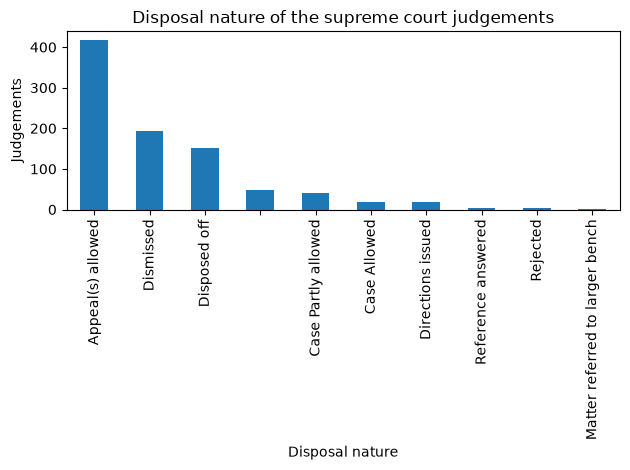

In [61]:
disposal_counts.plot(kind = "bar")
plt.title("Disposal nature of the supreme court judgements")
plt.xticks(rotation = 90)
plt.xlabel("Disposal nature")
plt.ylabel("Judgements")
plt.tight_layout()
plt.show()